In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath('../'))
from src.data_processing import (
    create_lag_features,
    standardize_features,
    create_XY
)

file_path = '../data/boston_weather_data_2.csv'
df = pd.read_csv(file_path)
candidate_features = ['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']

In [2]:
df['target_tomorrow_tavg'] = df['tavg'].shift(-1)

featureCorrelations = df[candidate_features].corrwith(df['target_tomorrow_tavg'], method = 'pearson')
print("the correlation of features with tmr's tavg")
print(featureCorrelations)
print('\n')

feature_corr_matrix = df[candidate_features].corr(method='pearson')

print("the correlation between each feature:")
print(feature_corr_matrix[['hum', 'uvi', 'tavg', 'wspd', 'wdir', 'pres', 'prcp']])

the correlation of features with tmr's tavg
hum     0.889483
uvi     0.787512
tavg    0.958117
wspd   -0.603002
wdir   -0.209369
pres    0.116534
prcp   -0.021052
dtype: float64


the correlation between each feature:
           hum       uvi      tavg      wspd      wdir      pres      prcp
hum   1.000000  0.729129  0.930165 -0.507044 -0.205901 -0.084722  0.129220
uvi   0.729129  1.000000  0.788113 -0.422559 -0.040162  0.082045 -0.166763
tavg  0.930165  0.788113  1.000000 -0.542671 -0.181006 -0.015993  0.032974
wspd -0.507044 -0.422559 -0.542671  1.000000  0.230360 -0.412289  0.087869
wdir -0.205901 -0.040162 -0.181006  0.230360  1.000000 -0.146881 -0.258837
pres -0.084722  0.082045 -0.015993 -0.412289 -0.146881  1.000000 -0.267582
prcp  0.129220 -0.166763  0.032974  0.087869 -0.258837 -0.267582  1.000000


In [ ]:
#select features and lag period for QML

available_features = ['hum', 'uvi', 'tavg', 'wspd']
# available_features: the features we select

X, Y = create_XY(df, available_features, lag_window = 4)

correlations = X.corrwith(Y, method = 'pearson')
print("the correlation of each feature_lag with tmr's temp:")
print(correlations)
print(f"# of rows of the dataset: {len(X)}\n")


# candidate_features2 = ['tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres']
# df_clean2 = df.dropna(subset = candidate_features2 + ['target_tomorrow_tavg'])

# correlations2 = df_clean2[candidate_features2].corrwith(df_clean2['target_tomorrow_tavg'], method = 'pearson')
# print("the correlation of each feature(without wdir) with tmr's temp:")
# print(correlations2)
# print(f"# of rows of the dataset: {len(df_clean2)}")

the correlation of each feature_lag with tmr's temp:
hum_lag1     0.839936
hum_lag2     0.821751
hum_lag3     0.821585
hum_lag4     0.821671
uvi_lag1     0.796039
uvi_lag2     0.799914
uvi_lag3     0.800678
uvi_lag4     0.800370
tavg_lag1    0.917556
tavg_lag2    0.902491
tavg_lag3    0.898031
tavg_lag4    0.892666
wspd_lag1   -0.574062
wspd_lag2   -0.549721
wspd_lag3   -0.541131
wspd_lag4   -0.533978
dtype: float64
# of rows of the dataset: 664



to what extend the synchronous trands of Tavg and Humidity match:


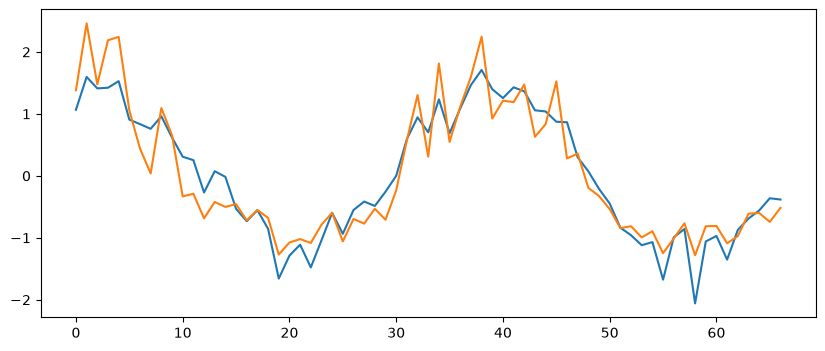

In [ ]:
#this is just a demonstration of the trends of Tavg and Humidity
data = pd.read_csv("../data/boston_weather_data_2.csv")
X = data[["tavg", "hum"]].values

tavg_col = X[:, 0]
hum_col = X[:, 1]

tavg_mean = np.mean(tavg_col)
hum_mean = np.mean(hum_col)

tavg_stdev = np.std(tavg_col)
hum_stdev = np.std(hum_col)

tavg_zscr = (X[:, 0] - tavg_mean) / tavg_stdev
hum_zscr = (X[:, 1] - hum_mean) / hum_stdev

Z = np.column_stack([tavg_zscr, hum_zscr])

step = 10
Z_plot = Z[::step]

plt.figure(figsize = (10, 4))
plt.plot(Z_plot[:,0], label = 'Tavg')
plt.plot(Z_plot[:,1], label = 'Humidity')

print("to what extend the synchronous trands of Tavg and Humidity match:")
plt.show()

In [6]:
#standardization
X_angle, means, stds, alphas = standardize_features(
    X,
    X.columns
)

print(X_angle.shape)

(664, 16)
